# 17 -- Checkpoint/resume validation

Confirms the GPU checkpointing scheme is actually correct, not just derived
on paper -- runs the SAME row several ways and diffs the results. Two
independent mechanisms, tested separately:

**Format A (extend a completed row to later cutoff times)**
- **Run A (ground truth)**: one continuous pass, `times` spanning the full
  range `[t_first, T_B]`.
- **Run B**: the same row, but only its first half of cutoff times --
  fully completes (so its last result file carries a plateau checkpoint).
- **Extend B**: `ptbuilder.ic.extend_2d_setup_times(setup_B, ...)` appends
  the remaining times to `setup_B`'s `times[]` IN PLACE, then
  `bubblemaster_gpu` is re-run on the SAME `setup_B`/`out_B` with no special
  flags -- auto-detection sees `n_t` now exceeds the result-file count and
  extends using the embedded plateau checkpoint.

**Format B (resume a run interrupted mid-stream, e.g. by walltime)**
- **Run D**: Run A's SAME setup, submitted with a deliberately short SLURM
  `--time` so it gets genuinely killed mid-stream, and a short
  `--checkpoint-interval-minutes` so at least one stream checkpoint gets
  written first.
- **Resume D**: `bubblemaster_gpu` re-run on the SAME `setup_A`/`out_D` with
  a normal walltime and no special flags -- auto-detection finds
  `checkpoint.h5` and resumes from wherever streaming left off.

If the checkpointing math is right, both should reproduce Run A's spectra
exactly (to floating-point precision) at every shared cutoff time.

**Workflow**
1. Run **Section 1** to write Run A/B's setups and submit them.
2. Once both finish, run **Section 2** to extend Run B in place and submit.
3. Run **Section 3** to compare Run A vs extended Run B (Format A).
4. Run **Section 4** to submit Run D's deliberately-interrupted attempt.
5. Once it's confirmed interrupted, run **Section 4**'s next cell to submit
   the resume, then the final cell to compare Run A vs resumed Run D
   (Format B).

In [1]:
from pathlib import Path
from types import SimpleNamespace

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import ptbuilder as pt
from ptbuilder.ic import BubbleMasterParams, write_2d_setup, extend_2d_setup_times
from ptbuilder.weight_scan_diagnostics import load_kinematics

REPO_ROOT   = Path(pt.__file__).parent.parent
LAMBDA_BAR  = 0.84
GAMMA_IJ    = 2.75   # cheap, well-tested row (matches the batch-size-scan calibration point)

CHECK_ROOT  = REPO_ROOT / 'data/checkpoint_validation'
setup_dir   = CHECK_ROOT / 'setups'
output_root = CHECK_ROOT / 'gpu'
setup_dir.mkdir(parents=True, exist_ok=True)
output_root.mkdir(parents=True, exist_ok=True)

instanton_path = REPO_ROOT / f'data/phi4_lambda_bar{LAMBDA_BAR:g}/instanton.h5'
kin = load_kinematics(instanton_path)

class CachedPhi4Potential:
    def __init__(self, lambda_bar):
        self.params = {'lambda_bar': float(lambda_bar)}
    def to_hdf5(self, group):
        group.attrs.create('type', 'phi4', dtype=h5py.string_dtype(encoding='ascii'))
        group.attrs['phi_false'] = 0.0
        group.attrs['phi_true']  = 1.0
        group.attrs['lambda_bar'] = self.params['lambda_bar']

model = SimpleNamespace(instanton=kin.profile, kinematics=kin,
                        potential=CachedPhi4Potential(LAMBDA_BAR))

def time_at_gamma(gamma):
    if gamma <= 1.0:
        return 0.0
    return brentq(lambda t: float(kin.Gamma(t)) - gamma, 0.0, 1.0e7)

t_first = time_at_gamma(GAMMA_IJ)
print(f'gamma_ij={GAMMA_IJ}  t_first={t_first:.3f}')

gamma_ij=2.75  t_first=17.748


## 1. Write the three setups + SLURM script

Run A gets 10 cutoff times spanning the full range. Run B gets the first 5
of those (identical values, so its own last time is directly comparable to
Run A's 5th). Run C (built after B's checkpoint exists) requests the
remaining 5.

In [2]:
N_TOTAL  = 10
# Must stay under this row's natural cutoff (~1.29*d): _cutoff_times floors
# t_max at max(natural, times[-1]), so if Run A's times[-1] pushed t_max
# above the natural value while Run B's own times[-1] did not, the two runs
# would use DIFFERENT t_max_base_ references -- silently invalidating this
# whole comparison (Run A and Run B/C would no longer be computing the same
# physical quantity). Asserted explicitly below rather than just trusted.
from ptbuilder.ic import _spatial_step, _two_bubble_ic
dz_target = _spatial_step(kin.profile, GAMMA_IJ, BubbleMasterParams(dz=None, wall_points=20))
_, _, d_row, _ = _two_bubble_ic(kin.profile, GAMMA_IJ, dz_target, 'mid')
natural_t_max = 1.29 * d_row   # cutoff_type=0 formula: t_cut + 7*t_0 = 1.08d + 0.21d

T_SPAN = 0.5 * (natural_t_max - t_first)   # comfortably under the natural cutoff
times_full = np.linspace(t_first, t_first + T_SPAN, N_TOTAL)
times_A  = times_full           # Run A: continuous, full range
times_B  = times_full[:5]       # Run B: first half only
times_C_expected = times_full[5:]   # what Run C should end up requesting

assert times_A[-1] < natural_t_max, (
    f'times_A[-1]={times_A[-1]:.3f} exceeds the natural t_max='
    f'{natural_t_max:.3f} for this row -- reduce T_SPAN, see comment above')

N_OMEGA, N_K = 32, 51
omega = np.geomspace(0.05, 5.0, N_OMEGA)   # arbitrary but fixed -- shared by A/B/C

params = BubbleMasterParams(
    dz=None, wall_points=20, n_w=N_OMEGA, n_k=N_K, how_often_ds=5,
    baby_steps=100, cutoff_type=0, t_0_scal=1.0, collision_radius='mid',
)

setup_A = setup_dir / 'runA_full.h5'
setup_B = setup_dir / 'runB_partial.h5'
write_2d_setup(model, GAMMA_IJ, times_A, setup_A, params, wlist=omega)
write_2d_setup(model, GAMMA_IJ, times_B, setup_B, params, wlist=omega)

# Direct, ground-truth check (not just trusting the formula reasoning above):
# read back t_cut/t_m/t_max/smax from both written setups and require an
# exact match -- this is the actual invariant checkpointing depends on.
with h5py.File(setup_A) as fA, h5py.File(setup_B) as fB:
    for key in ('t_cut', 't_m', 't_max', 'smax', 't_0', 'd'):
        vA, vB = float(fA.attrs[key]), float(fB.attrs[key])
        assert vA == vB, f'setup_A/{key}={vA} != setup_B/{key}={vB} -- see T_SPAN comment above'
print('Confirmed: Run A and Run B share identical t_cut/t_m/t_max/smax/t_0/d.')

print(f'Run A: {len(times_A)} times, {times_A[0]:.3f}..{times_A[-1]:.3f}')
print(f'Run B: {len(times_B)} times, {times_B[0]:.3f}..{times_B[-1]:.3f}')
print(f'(Run C setup is written in Section 2, after Run B has produced a checkpoint)')

out_A = output_root / 'runA'
out_B = output_root / 'runB'
out_A.mkdir(exist_ok=True)
out_B.mkdir(exist_ok=True)

scripts_dir = REPO_ROOT / 'scripts'
logs_dir    = REPO_ROOT / 'logs'
scripts_dir.mkdir(exist_ok=True)
logs_dir.mkdir(exist_ok=True)

script_path = scripts_dir / 'checkpoint_validation_gpu.sh'
script_path.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_checkpoint_validation
#SBATCH --output={logs_dir.relative_to(REPO_ROOT)}/checkpoint_validation_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A m3166_g
#SBATCH --nodes=1
#SBATCH --ntasks=2
#SBATCH --ntasks-per-node=2
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time=00:20:00
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu {setup_A.relative_to(REPO_ROOT)} {out_A.relative_to(REPO_ROOT)}/ --param 128 --filon-panels-per-osc 40 --s-batch-size 128 &
srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu {setup_B.relative_to(REPO_ROOT)} {out_B.relative_to(REPO_ROOT)}/ --param 128 --filon-panels-per-osc 40 --s-batch-size 128 &
wait
''')
script_path.chmod(0o755)
print(f'Written: {script_path.relative_to(REPO_ROOT)}')
print(f'Submit: sbatch {script_path.relative_to(REPO_ROOT)}')

Confirmed: Run A and Run B share identical t_cut/t_m/t_max/smax/t_0/d.
Run A: 10 times, 17.748..33.456
Run B: 5 times, 17.748..24.729
(Run C setup is written in Section 2, after Run B has produced a checkpoint)
Written: scripts/checkpoint_validation_gpu.sh
Submit: sbatch scripts/checkpoint_validation_gpu.sh


## 2. After Run A/B complete: extend Run B in place (Format A)

Extends `setup_B`'s own `times[]` in place to cover the remaining range,
then re-runs `bubblemaster_gpu` on the SAME `setup_B`/`out_B` -- no
`--resume-from`-style flag, no new setup file. Auto-detection sees `n_t` now
exceeds `out_B`'s existing result-file count and extends using the plateau
checkpoint embedded in `result_0004.h5` by Run B's own completion.

In [3]:
last_B = out_B / f'result_{len(times_B)-1:04d}.h5'
if not last_B.exists():
    raise FileNotFoundError(
        f'{last_B} not found -- submit and wait for '
        f'scripts/checkpoint_validation_gpu.sh (Run A + Run B) first')
with h5py.File(last_B) as f:
    if 'plateau_re' not in f:
        raise RuntimeError(
            f'{last_B} has no plateau checkpoint -- Run B did not complete '
            f'successfully (or was produced by an older build)')

extend_2d_setup_times(setup_B, times_C_expected)
print(f'Extended setup_B in place: now requests {len(times_full)} times total '
      f'(unchanged {times_B[0]:.3f}..{times_B[-1]:.3f}, new '
      f'{times_C_expected[0]:.3f}..{times_C_expected[-1]:.3f})')

script_path_extend = REPO_ROOT / 'scripts' / 'checkpoint_validation_extend_gpu.sh'
script_path_extend.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_checkpoint_validation_extend
#SBATCH --output=logs/checkpoint_validation_extend_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A m3166_g
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time=00:15:00
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu {setup_B.relative_to(REPO_ROOT)} {out_B.relative_to(REPO_ROOT)}/ --param 128 --filon-panels-per-osc 40 --s-batch-size 128
''')
script_path_extend.chmod(0o755)
print(f'Written: {script_path_extend.relative_to(REPO_ROOT)}')
print(f'Submit: sbatch {script_path_extend.relative_to(REPO_ROOT)}')

FileNotFoundError: /Users/malte/Simulations/PhaseTransitionBuilder/data/checkpoint_validation/gpu/runB/result_0004.h5 not found -- submit and wait for scripts/checkpoint_validation_gpu.sh (Run A + Run B) first

## 3. Compare Run A vs extended Run B (Format A)

Extended Run B writes its new results at the SAME global indices Run A
uses for those times (5..9), so no index offset bookkeeping is needed --
just compare index-for-index.

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/malte/Simulations/PhaseTransitionBuilder/data/checkpoint_validation/gpu/runA/result_0005.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

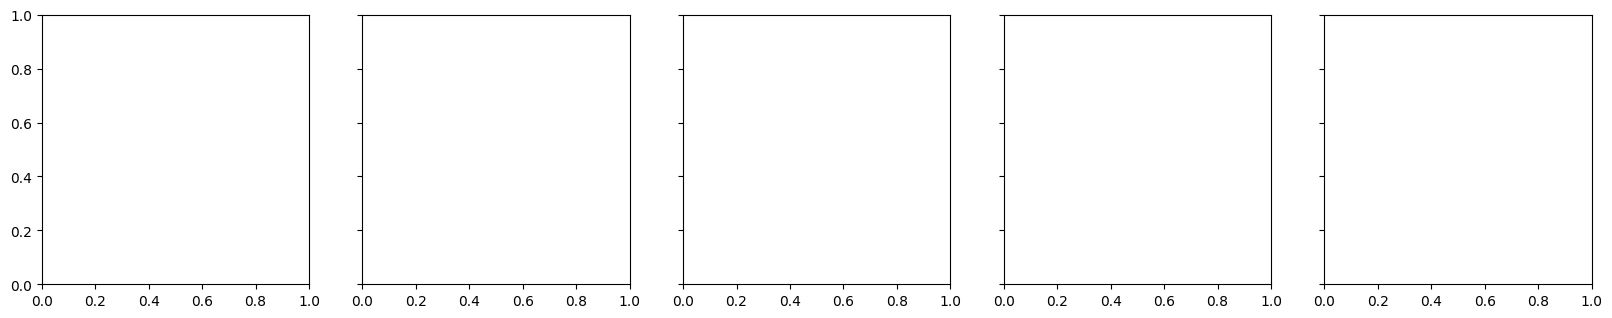

In [4]:
def load_result(out_dir, i_t):
    with h5py.File(out_dir / f'result_{i_t:04d}.h5') as f:
        return f['w'][:], f['spectrum'][:]

n_A = len(times_A)
extended_indices = list(range(len(times_B), n_A))   # 5..9

max_rel_diffs = []
fig, axes = plt.subplots(1, len(extended_indices), figsize=(4*len(extended_indices), 3.5), sharey=True)
if len(extended_indices) == 1:
    axes = [axes]

for j, i_t in enumerate(extended_indices):
    w_A, spec_A = load_result(out_A, i_t)
    w_B, spec_B = load_result(out_B, i_t)

    if not np.allclose(w_A, w_B):
        raise RuntimeError(f'w grids differ between Run A and extended Run B at index {i_t} -- '
                           f'not a valid comparison')

    peak = spec_A.max()
    mask = spec_A >= 1e-3 * peak
    rel = np.abs(spec_B[mask] - spec_A[mask]) / np.abs(spec_A[mask])
    max_rel_diffs.append(rel.max() if rel.size else float('nan'))

    ax = axes[j]
    ax.plot(w_A, spec_A, color='k', lw=2, label='Run A (continuous)')
    ax.plot(w_B, spec_B, color='tab:red', lw=1.5, ls='--', label='Run B extended (Format A)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f't={times_A[i_t]:.2f}\nmax rel diff={max_rel_diffs[-1]*100:.2e}%')
    ax.set_xlabel('w')
    if j == 0:
        ax.set_ylabel('spectrum')
        ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'checkpoint_validation_format_a.pdf', bbox_inches='tight')
plt.show()

print()
print('Format A (extend a completed row): max relative difference at each shared cutoff time:')
for i_t, d in zip(extended_indices, max_rel_diffs):
    print(f'  t={times_A[i_t]:.3f}: {d*100:.2e}%')
worst = max(max_rel_diffs)
print()
if worst < 1e-6:
    print(f'PASS: worst-case relative difference {worst*100:.2e}% -- consistent with '
          f'floating-point roundoff. Extending a completed row reproduces the '
          f'continuous run exactly.')
else:
    print(f'FAIL: worst-case relative difference {worst*100:.2e}% -- larger than '
          f'floating-point roundoff would explain. Something in the plateau-checkpoint '
          f'math does not match a continuous run -- do not trust extending a row until '
          f'this is understood.')

## 4. Format B validation: interrupted mid-stream, then resumed

Unlike Format A, this needs a GENUINE interruption -- there's no cheap way
to fabricate a partial stream checkpoint from Python. Submits Run A's SAME
setup to a fresh output dir with a deliberately short SLURM `--time` (so it
gets killed by SLURM before finishing) and a short
`--checkpoint-interval-minutes` (so at least one stream checkpoint gets
written before the kill). A second submission with a normal walltime and no
special flags then auto-detects `checkpoint.h5` and resumes.

In [5]:
out_D = output_root / 'runD_interrupted'
out_D.mkdir(exist_ok=True)

script_path_D1 = REPO_ROOT / 'scripts' / 'checkpoint_validation_interrupt_gpu.sh'
script_path_D1.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_checkpoint_validation_interrupt
#SBATCH --output=logs/checkpoint_validation_interrupt_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A m3166_g
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time=00:01:00
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu {setup_A.relative_to(REPO_ROOT)} {out_D.relative_to(REPO_ROOT)}/ --param 128 --filon-panels-per-osc 40 --s-batch-size 128 --checkpoint-interval-minutes 0.02
''')
script_path_D1.chmod(0o755)
print(f'Written: {script_path_D1.relative_to(REPO_ROOT)}')
print(f'Submit: sbatch {script_path_D1.relative_to(REPO_ROOT)}')
print()
print('This job has a deliberately short --time (1 min) so SLURM kills it before it')
print('finishes -- that IS the test (a real walltime interruption, not a simulated one).')
print('If GAMMA_IJ finishes in well under a minute even with --checkpoint-interval-minutes')
print('0.02, shorten --time further and resubmit before continuing to the next cell.')

Written: scripts/checkpoint_validation_interrupt_gpu.sh
Submit: sbatch scripts/checkpoint_validation_interrupt_gpu.sh

This job has a deliberately short --time (1 min) so SLURM kills it before it
finishes -- that IS the test (a real walltime interruption, not a simulated one).
If GAMMA_IJ finishes in well under a minute even with --checkpoint-interval-minutes
0.02, shorten --time further and resubmit before continuing to the next cell.


In [6]:
n_results_D = sum((out_D / f'result_{i:04d}.h5').exists() for i in range(len(times_A)))
checkpoint_D = out_D / 'checkpoint.h5'

if n_results_D == len(times_A):
    print(f'Run D already completed ({n_results_D}/{len(times_A)} results) in the first '
          f'submission -- --time was not short enough to interrupt it. Shorten '
          f'scripts/checkpoint_validation_interrupt_gpu.sh\'s --time (or lengthen '
          f'--checkpoint-interval-minutes is NOT the fix here -- shorten --time) and '
          f'resubmit to actually exercise Format B.')
elif not checkpoint_D.exists():
    raise FileNotFoundError(
        f'{checkpoint_D} not found and only {n_results_D}/{len(times_A)} results exist -- '
        f'submit and wait for scripts/checkpoint_validation_interrupt_gpu.sh first')
else:
    print(f'Confirmed interrupted mid-stream: {n_results_D}/{len(times_A)} results, '
          f'checkpoint.h5 present -- submitting the resume.')

    script_path_D2 = REPO_ROOT / 'scripts' / 'checkpoint_validation_resume_gpu.sh'
    script_path_D2.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_checkpoint_validation_resume
#SBATCH --output=logs/checkpoint_validation_resume_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A m3166_g
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time=00:15:00
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu {setup_A.relative_to(REPO_ROOT)} {out_D.relative_to(REPO_ROOT)}/ --param 128 --filon-panels-per-osc 40 --s-batch-size 128
''')
    script_path_D2.chmod(0o755)
    print(f'Written: {script_path_D2.relative_to(REPO_ROOT)}')
    print(f'Submit: sbatch {script_path_D2.relative_to(REPO_ROOT)}')

FileNotFoundError: /Users/malte/Simulations/PhaseTransitionBuilder/data/checkpoint_validation/gpu/runD_interrupted/checkpoint.h5 not found and only 0/10 results exist -- submit and wait for scripts/checkpoint_validation_interrupt_gpu.sh first

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/malte/Simulations/PhaseTransitionBuilder/data/checkpoint_validation/gpu/runA/result_0000.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

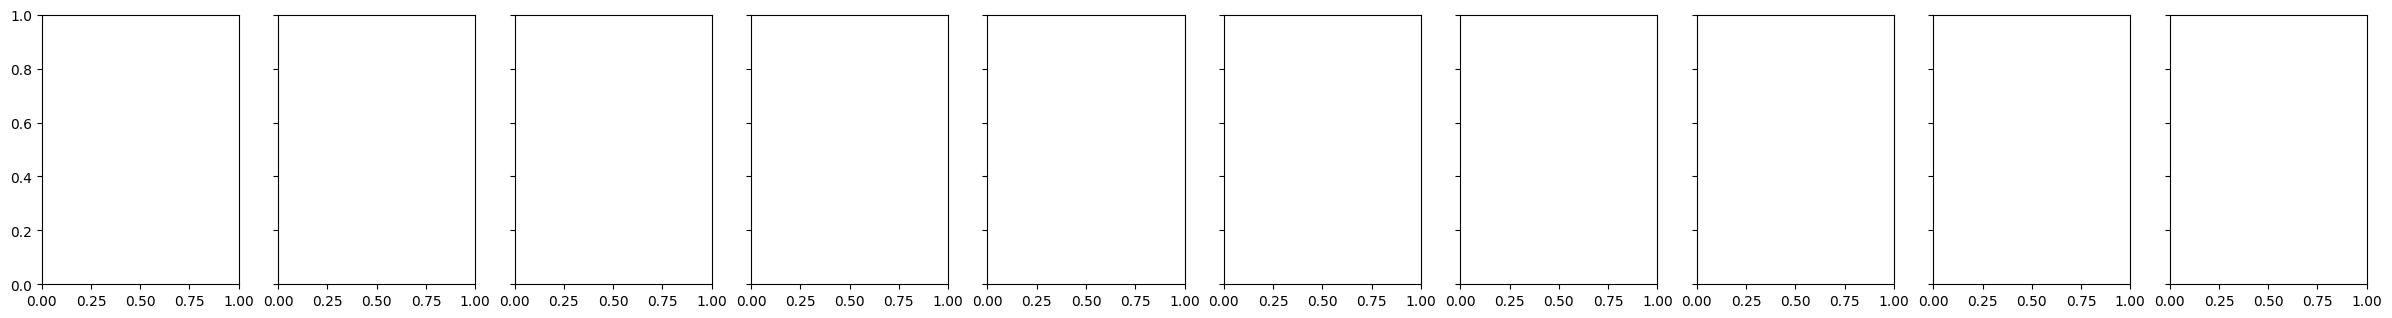

In [7]:
n_A = len(times_A)
max_rel_diffs_D = []
fig, axes = plt.subplots(1, n_A, figsize=(3*n_A, 3.5), sharey=True)

for i_t in range(n_A):
    w_A, spec_A = load_result(out_A, i_t)
    w_D, spec_D = load_result(out_D, i_t)

    if not np.allclose(w_A, w_D):
        raise RuntimeError(f'w grids differ between Run A and Run D at index {i_t} -- '
                           f'not a valid comparison')

    peak = spec_A.max()
    mask = spec_A >= 1e-3 * peak
    rel = np.abs(spec_D[mask] - spec_A[mask]) / np.abs(spec_A[mask])
    max_rel_diffs_D.append(rel.max() if rel.size else float('nan'))

    ax = axes[i_t]
    ax.plot(w_A, spec_A, color='k', lw=2, label='Run A (continuous)')
    ax.plot(w_D, spec_D, color='tab:blue', lw=1.5, ls='--', label='Run D (interrupted+resumed)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f't={times_A[i_t]:.2f}\nmax rel diff={max_rel_diffs_D[-1]*100:.2e}%')
    ax.set_xlabel('w')
    if i_t == 0:
        ax.set_ylabel('spectrum')
        ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'checkpoint_validation_format_b.pdf', bbox_inches='tight')
plt.show()

print()
print('Format B (interrupted mid-stream, then resumed): max relative difference at each cutoff time:')
for t, d in zip(times_A, max_rel_diffs_D):
    print(f'  t={t:.3f}: {d*100:.2e}%')
worst_D = max(max_rel_diffs_D)
print()
if worst_D < 1e-6:
    print(f'PASS: worst-case relative difference {worst_D*100:.2e}% -- consistent with '
          f'floating-point roundoff. Resuming an interrupted stream reproduces the '
          f'continuous run exactly.')
else:
    print(f'FAIL: worst-case relative difference {worst_D*100:.2e}% -- larger than '
          f'floating-point roundoff would explain. Something in the stream-checkpoint '
          f'resume does not match a continuous run -- do not trust it until this is '
          f'understood.')